## Summary of the Comparison Process

- **Message generation:**  
  A synthetic watermark message was produced as a multi-channel tensor with discrete values mapped to the 0–255 range.

- **Message visualization:**  
  Each channel of the generated message was displayed to inspect the underlying pattern.

- **Encoder is applied to the cover + secret image, the same as I did in training**

- **PNG conversion and saving:**  
  The tensor was converted into a PIL image and saved as a PNG file, introducing `uint8` quantization, using 2 options.

- **PNG reloading:**  
  The saved image was loaded back from disk for numerical comparison with the original secret.

- **PSNR and ACC are affected by quatization**

**But my question is why Davide results are not affected by this?, Did Davide compute online or offline evaluation? I think offline (reading the container images (cover + secret) from disk, in that case his results were not affected to much as mine. Am I doing something wrong?**

In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
%reload_ext autoreload

In [2]:
import numpy as np
import torch
from pathlib import Path
import matplotlib.pyplot as plt
import torchvision.transforms as T

In [3]:
from utils_nb import generate_message_image, visualize_message_image, read_image_pil, show_pil_image, build_models, load_weights, reverse_message_image
from utils_nb import ssim, psnr, show_tensor_image

## Steganography with 8 BPPs

In [4]:
img_size = (256,256)
bpp = 8
device_name = 'cuda:0'
device = torch.device(device_name)

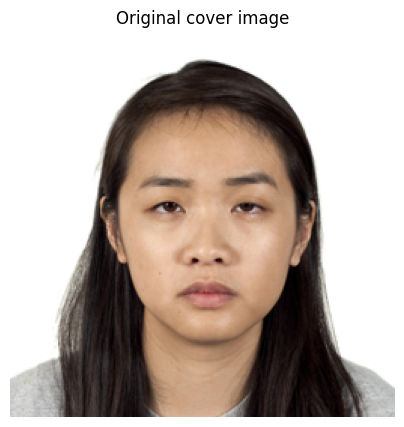

In [5]:
cover_image_path = Path('/app/facial_data/CFD/processed/test/AF201_060_N.jpg')
img_cover = read_image_pil(cover_image_path, img_size)
show_pil_image(img_cover, 'Original cover image', (5,5))

In [6]:
# range of the image (cover)
img_cover_np = np.array(img_cover)
print(f'range: min:{np.min(img_cover_np)} to max:{np.max(img_cover_np)}')

range: min:0 to max:255


**Creating a sequence of numbers with a range of 0–15 across two channels represents 8 bpp.**

In [7]:
message_flat, message_image = generate_message_image(im_size = img_size, bpp = bpp)
print(f'range: min:{min(message_flat)} to max:{max(message_flat)} -->{message_flat}')

range: min:0 to max:15 -->[ 8 15  7 ...  9 15  3]


In [8]:
# this is neccesary to use the stegformer (steganography) model
message_image

tensor([[[128., 240., 112.,  ..., 208., 144., 144.],
         [128., 112.,  96.,  ...,  48., 192.,  48.],
         [  0.,   0.,  80.,  ..., 144., 192., 128.],
         ...,
         [112., 176.,  64.,  ...,  48., 192.,  16.],
         [  0.,  96., 128.,  ...,  80.,  96.,  16.],
         [ 32.,  32., 192.,  ...,  96., 144., 208.]],

        [[ 96.,  80., 128.,  ...,  16., 160., 208.],
         [ 32.,  64., 240.,  ...,  96., 128.,   0.],
         [208., 224., 144.,  ..., 208.,  80., 224.],
         ...,
         [ 16.,   0., 240.,  ..., 112., 192.,  96.],
         [ 32., 208., 160.,  ..., 192.,  64.,  32.],
         [160., 112., 176.,  ..., 144., 240.,  48.]]])

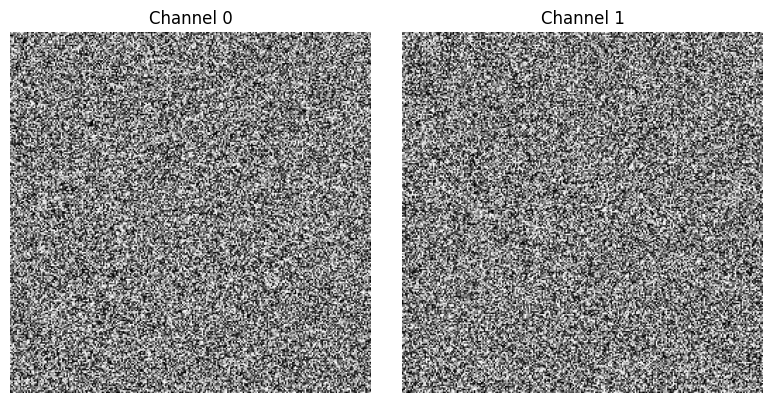

In [9]:
# how the watermark as image looks like
visualize_message_image(message_image)

### Normalization

In [10]:
# message image, the model receive the image message normalized
message_image_norm = message_image/255.0
print(f'range: min:{message_image_norm.min()} to max:{message_image_norm.max()}')

range: min:0.0 to max:0.9411764740943909


In [11]:
# cover image, also for the cover image
img_cover_norm = T.ToTensor()(img_cover)
print(f'range: min:{img_cover_norm.min()} to max:{img_cover_norm.max()}')

range: min:0.0 to max:1.0


In [12]:
# move to gpu 
cover = img_cover_norm.unsqueeze(0).to(device)
secret = message_image_norm.unsqueeze(0).to(device)

In [13]:
cover.shape, secret.shape

(torch.Size([1, 3, 256, 256]), torch.Size([1, 2, 256, 256]))

In [14]:
# concatenate as the input to the encoder
msg = torch.cat([cover, secret], 1)
msg.shape

torch.Size([1, 5, 256, 256])

### load the model

In [22]:
# this model was previouly trained on celeba, It is needed to create with the same parameters 
encoder, decoder = build_models(image_size=img_size[0], secret_channels=secret.shape[1])
encoder.to(device); decoder.to(device)

Using StegFormer-B model with default parameters


StegFormer(
  (embedding): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (encoderlayer_0): CATB_Layer(
    (blocks): ModuleList(
      (0): Channel_Adaptive_Transformer_Block(
        (transformer_block): Swin_Transformer(
          (blocks): ModuleList(
            (0-1): 2 x SwinTransformerBlock(
              (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
              (attn): WindowAttention(
                (qkv): Linear(in_features=64, out_features=192, bias=True)
                (attn_drop): Dropout(p=0.0, inplace=False)
                (proj): Linear(in_features=64, out_features=64, bias=True)
                (proj_drop): Dropout(p=0.0, inplace=False)
                (softmax): Softmax(dim=-1)
              )
              (drop_path): Identity()
              (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
              (mlp): Mlp(
                (fc1): Linear(in_features=64, out_features=256, bias=True)
                (act):

In [23]:
# load weights
model_path = Path('/app/runs/2_8_clamp_StegFormer-B_baseline/celeba_hq/model')
load_weights(
    encoder=encoder,
    decoder=decoder,
    save_path=model_path,
    tag='ACC',  # decide what is better to restore: 'psnr', 'ssim' 'last' or 'acc'
    )

🔄 Restoring checkpoint from 'ACC'...
✅ Loaded weights from /app/runs/2_8_clamp_StegFormer-B_baseline/celeba_hq/model with tag 'ACC'


In [24]:
encoder.eval(); decoder.eval()

StegFormer(
  (embedding): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (encoderlayer_0): CATB_Layer(
    (blocks): ModuleList(
      (0): Channel_Adaptive_Transformer_Block(
        (transformer_block): Swin_Transformer(
          (blocks): ModuleList(
            (0-1): 2 x SwinTransformerBlock(
              (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
              (attn): WindowAttention(
                (qkv): Linear(in_features=64, out_features=192, bias=True)
                (attn_drop): Dropout(p=0.0, inplace=False)
                (proj): Linear(in_features=64, out_features=64, bias=True)
                (proj_drop): Dropout(p=0.0, inplace=False)
                (softmax): Softmax(dim=-1)
              )
              (drop_path): Identity()
              (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
              (mlp): Mlp(
                (fc1): Linear(in_features=64, out_features=256, bias=True)
                (act):

### Apply the encoder

In [25]:
encode_img = encoder(msg)
encode_img # this is the container (cover + secret)

tensor([[[[0.9683, 0.9857, 0.9990,  ..., 0.9928, 0.9909, 0.9924],
          [1.0010, 0.9958, 0.9850,  ..., 0.9904, 0.9943, 0.9788],
          [0.9843, 0.9905, 0.9903,  ..., 0.9925, 0.9886, 0.9950],
          ...,
          [0.7953, 0.8184, 0.8438,  ..., 0.7290, 0.7260, 0.7509],
          [0.7919, 0.8016, 0.8271,  ..., 0.6936, 0.7438, 0.7710],
          [0.7875, 0.7967, 0.8322,  ..., 0.7168, 0.7713, 0.6601]],

         [[0.9251, 0.9713, 0.9825,  ..., 0.9865, 0.9723, 0.9650],
          [0.9767, 0.9869, 0.9853,  ..., 0.9863, 0.9814, 0.9867],
          [0.9954, 0.9874, 0.9950,  ..., 0.9842, 0.9873, 0.9887],
          ...,
          [0.7808, 0.7986, 0.8408,  ..., 0.7246, 0.7106, 0.7375],
          [0.8200, 0.7977, 0.8359,  ..., 0.6955, 0.7616, 0.7592],
          [0.8293, 0.7991, 0.8069,  ..., 0.7098, 0.7608, 0.6306]],

         [[0.9202, 0.9712, 0.9920,  ..., 0.9848, 0.9882, 0.9818],
          [0.9754, 0.9920, 0.9912,  ..., 0.9970, 0.9968, 0.9818],
          [0.9853, 0.9920, 0.9936,  ..., 0

In [26]:
print(f'range: min:{encode_img.min()} to max:{encode_img.max()}')

range: min:-0.0044959187507629395 to max:1.0097075700759888


In [27]:
# apply clamp, this is a proposal from the paper, is also done in training
encode_img_c = torch.clamp(encode_img, 0, 1)
print(f'range: min:{encode_img_c.min()} to max:{encode_img_c.max()}')

range: min:0.0 to max:1.0


### Apply the decoder

In [28]:
decode_img = decoder(encode_img_c)
decode_img # --> this is the message image recovered

tensor([[[[ 0.5402,  0.9358,  0.4425,  ...,  0.8309,  0.5810,  0.5567],
          [ 0.4693,  0.4679,  0.3802,  ...,  0.1707,  0.7338,  0.1495],
          [ 0.0114,  0.0020,  0.3298,  ...,  0.5564,  0.7741,  0.4852],
          ...,
          [ 0.4455,  0.7022,  0.2615,  ...,  0.1838,  0.7306,  0.0787],
          [ 0.0037,  0.3855,  0.5059,  ...,  0.3107,  0.4478,  0.0740],
          [ 0.1897,  0.1351,  0.7472,  ...,  0.3887,  0.5723,  0.7619]],

         [[ 0.3817,  0.3081,  0.4956,  ...,  0.0903,  0.6331,  0.7403],
          [ 0.1613,  0.2529,  0.9599,  ...,  0.3807,  0.5494,  0.0030],
          [ 0.8206,  0.8778,  0.5687,  ...,  0.8345,  0.3045,  0.8711],
          ...,
          [ 0.0753, -0.0034,  0.9513,  ...,  0.4347,  0.7631,  0.3933],
          [ 0.1234,  0.8595,  0.6334,  ...,  0.7685,  0.2457,  0.2026],
          [ 0.6755,  0.4240,  0.6916,  ...,  0.5834,  0.8785,  0.1812]]]],
       device='cuda:0', grad_fn=<ConvolutionBackward0>)

In [29]:
print(f'range: min:{decode_img.min()} to max:{decode_img.max()}')

range: min:-0.05000555142760277 to max:0.9862462282180786


In [30]:
decode_img_c = torch.clamp(decode_img, 0.0, 1.0)
print(f'range: min:{decode_img_c.min()} to max:{decode_img_c.max()}')

range: min:0.0 to max:0.9862462282180786


### Metrics

In [31]:
from torchmetrics import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

/opt/conda/lib/python3.10/site-packages/torchmetrics/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [32]:
cal_psnr = PeakSignalNoiseRatio().to(device)
cal_ssim = StructuralSimilarityIndexMeasure().to(device)

#### If we compared the recovered secret and the original secret as images

In [33]:
# comparison between original secret and recovered secret (but not as images)
print('PNSR: Original secret vs recovered secret (Normalized arrays)')
psnr(secret, decode_img_c, cal_psnr)

PNSR: Original secret vs recovered secret (Normalized arrays)


array(42.01579, dtype=float32)

In [34]:
print('SSIM: Original secret vs recovered secret (Normalized arrays)')
ssim(secret, decode_img_c, cal_ssim)

SSIM: Original secret vs recovered secret (Normalized arrays)


array(0.9997075, dtype=float32)

#### if we go back to our original message sequence

In [35]:
recovered_msg, msg_img = reverse_message_image(decode_img, bpp)
recovered_msg

tensor([[[[ 8.6089, 14.9141,  7.0528,  ..., 13.2424,  9.2604,  8.8727],
          [ 7.4789,  7.4571,  6.0589,  ...,  2.7209, 11.6947,  2.3819],
          [ 0.1814,  0.0326,  5.2560,  ...,  8.8669, 12.3368,  7.7322],
          ...,
          [ 7.1007, 11.1920,  4.1679,  ...,  2.9298, 11.6444,  1.2551],
          [ 0.0595,  6.1433,  8.0623,  ...,  4.9523,  7.1373,  1.1800],
          [ 3.0241,  2.1539, 11.9077,  ...,  6.1944,  9.1209, 12.1422]],

         [[ 6.0840,  4.9108,  7.8979,  ...,  1.4388, 10.0902, 11.7991],
          [ 2.5712,  4.0304, 15.0000,  ...,  6.0669,  8.7568,  0.0481],
          [13.0783, 13.9895,  9.0629,  ..., 13.2996,  4.8534, 13.8825],
          ...,
          [ 1.1995,  0.0000, 15.0000,  ...,  6.9288, 12.1626,  6.2677],
          [ 1.9665, 13.6978, 10.0941,  ..., 12.2479,  3.9154,  3.2284],
          [10.7662,  6.7571, 11.0226,  ...,  9.2974, 14.0014,  2.8877]]]],
       device='cuda:0', grad_fn=<ClampBackward1>)

In [36]:
recovered_msg_flatten = torch.round(recovered_msg).long().flatten()
recovered_msg_flatten # --> this is our recovered original sequence

tensor([ 9, 15,  7,  ...,  9, 14,  3], device='cuda:0')

In [37]:
recovered_msg_flatten.shape, message_flat.shape

(torch.Size([131072]), (131072,))

In [38]:
# compute BER (Bit Error Rate)
correct_predictions = torch.sum(torch.tensor(message_flat) == recovered_msg_flatten.detach().cpu()).item()
correct_predictions

130308

In [39]:
total_elements = recovered_msg_flatten.numel()
total_elements

131072

In [40]:
print('ACC = 1 - BER:')
pixel_acc = correct_predictions / total_elements
pixel_acc

ACC = 1 - BER:


0.994171142578125

**The metrics were very high, this is the online scenario (the ideal), but what happend if we store the container as a image?**

### Saving the container (cover + secret) as a image 

In [41]:
from torchvision.transforms.functional import to_pil_image
from torchvision.utils import save_image
from torchvision.io import read_image

In [42]:
save_path_full_1 = Path('/app/image/container_test.png')
save_path_full_2 = Path('/app/image/container_test_2.png')

**We need to store the clamp version because is the input for the decoder**

In [43]:
# saving option 1
pil = to_pil_image(encode_img_c[0].detach().cpu()) 
pil.save(save_path_full_1, format="PNG", compress_level=0)

In [44]:
# saving option 2 
save_image(encode_img_c[0].cpu(), save_path_full_2)

#### Reading back the image

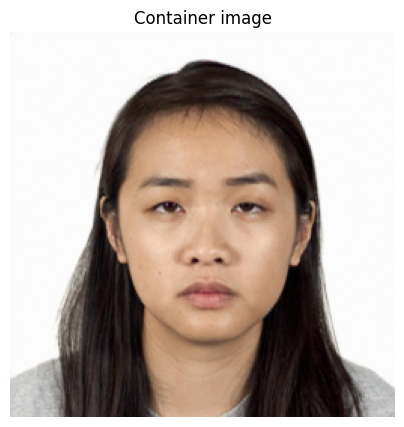

In [45]:
# option 1
img_container = read_image_pil(save_path_full_1, img_size)
show_pil_image(img_container, 'Container image', (5,5))

In [46]:
# the image was quantized
img_container_np = np.array(img_container)
print(f'range: min:{np.min(img_container_np)} to max:{np.max(img_container_np)}')

range: min:0 to max:255


In [50]:
psnr(torch.from_numpy(np.array(img_cover)).to('cpu'), torch.from_numpy(img_container_np), cal_psnr)

array(39.514668, dtype=float32)

In [141]:
# apply decoder again but before normalized
img_container_norm = T.ToTensor()(img_container_np)
container = img_container_norm.unsqueeze(0).to(device)
print(f'range: min:{container.min()} to max:{container.max()}')

range: min:0.0 to max:1.0


In [142]:
decode_img_offline = decoder(container)
decode_img_offline

tensor([[[[ 0.8137,  0.5242,  0.1540,  ...,  0.4031,  0.5249,  0.5150],
          [ 0.8330,  0.4352,  0.6370,  ...,  0.8074,  0.4894,  0.7170],
          [ 0.2137,  0.0726,  0.2449,  ...,  0.8470,  0.2429,  0.8690],
          ...,
          [ 0.3307,  0.6656,  0.3464,  ...,  0.8232,  0.9437,  0.7676],
          [ 0.2859,  0.1268,  0.1274,  ...,  0.2775,  0.5533,  0.8429],
          [ 0.4220,  0.2537,  0.5749,  ...,  0.1999,  0.0835,  0.5860]],

         [[ 0.4734,  0.5508,  0.4203,  ...,  0.8525,  0.2273,  0.0296],
          [ 0.9562,  0.4932,  0.6223,  ..., -0.0713,  0.3992,  0.2705],
          [ 0.1539, -0.0191,  0.5437,  ...,  0.9061,  0.6623,  1.0055],
          ...,
          [ 0.5856,  0.6926,  0.7289,  ...,  0.1857,  0.4283,  0.4256],
          [ 0.8543,  0.2384,  0.4900,  ...,  0.8470,  0.5383,  0.8687],
          [ 0.4040,  0.1135,  0.7323,  ...,  0.8394,  0.1052, -0.0026]]]],
       device='cuda:0', grad_fn=<ConvolutionBackward0>)

In [143]:
print(f'range: min:{decode_img_offline.min()} to max:{decode_img_offline.max()}')

range: min:-0.3207159638404846 to max:1.2286872863769531


In [144]:
decode_img_offline_c = torch.clamp(decode_img_offline, 0.0, 1.0)
print(f'range: min:{decode_img_offline_c.min()} to max:{decode_img_offline_c.max()}')

range: min:0.0 to max:1.0


In [145]:
# comparison between original secret and recovered secret offline (but not as images)
print('PNSR: Original secret vs recovered secret (Normalized arrays)')
psnr(secret, decode_img_offline_c, cal_psnr)

PNSR: Original secret vs recovered secret (Normalized arrays)


array(21.245861, dtype=float32)

In [146]:
print('SSIM: Original secret vs recovered secret (Normalized arrays)')
ssim(secret, decode_img_offline_c, cal_ssim)

SSIM: Original secret vs recovered secret (Normalized arrays)


array(0.9592302, dtype=float32)

#### Accuracy 

In [191]:
recovered_msg_offline, msg_img_offline = reverse_message_image(decode_img_offline, bpp)
recovered_msg_offline

tensor([[[[12.9686,  8.3541,  2.4540,  ...,  6.4243,  8.3660,  8.2076],
          [13.2760,  6.9355, 10.1527,  ..., 12.8677,  7.7990, 11.4272],
          [ 3.4055,  1.1568,  3.9026,  ..., 13.4983,  3.8706, 13.8497],
          ...,
          [ 5.2700, 10.6074,  5.5204,  ..., 13.1198, 15.0000, 12.2342],
          [ 4.5570,  2.0216,  2.0309,  ...,  4.4232,  8.8176, 13.4332],
          [ 6.7249,  4.0436,  9.1619,  ...,  3.1858,  1.3309,  9.3391]],

         [[ 7.5452,  8.7791,  6.6982,  ..., 13.5869,  3.6225,  0.4721],
          [15.0000,  7.8610,  9.9178,  ...,  0.0000,  6.3619,  4.3104],
          [ 2.4528,  0.0000,  8.6646,  ..., 14.4405, 10.5552, 15.0000],
          ...,
          [ 9.3330, 11.0384, 11.6162,  ...,  2.9596,  6.8264,  6.7837],
          [13.6152,  3.7993,  7.8095,  ..., 13.4992,  8.5796, 13.8456],
          [ 6.4387,  1.8089, 11.6715,  ..., 13.3784,  1.6761,  0.0000]]]],
       device='cuda:0', grad_fn=<ClampBackward1>)

In [192]:
recovered_msg_flatten_offline = torch.round(recovered_msg_offline).long().flatten()
recovered_msg_flatten_offline

tensor([13,  8,  2,  ..., 13,  2,  0], device='cuda:0')

In [193]:
# compute BER (Bit Error Rate)
correct_predictions = torch.sum(torch.tensor(message_flat) == recovered_msg_flatten_offline.detach().cpu()).item()
correct_predictions

42354

In [194]:
print('ACC = 1 - BER:')
pixel_acc = correct_predictions / total_elements
pixel_acc

ACC = 1 - BER:


0.3231353759765625

### Option 2

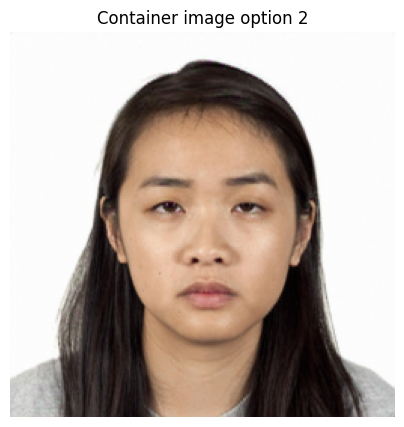

In [202]:
# option 2
img_container_2 = read_image(str(save_path_full_2))
show_tensor_image(img_container_2, 'Container image option 2', (5,5))

In [221]:
# the image was quantized
print(f'range: min:{img_container_2.min()} to max:{img_container_2.max()}')

range: min:0 to max:255


In [222]:
# apply decoder again but before normalized
img_container_norm_2 = img_container_2/255.0
container_2 = img_container_norm_2.unsqueeze(0).to(device)
print(f'range: min:{container_2.min()} to max:{container_2.max()}')

range: min:0.0 to max:1.0


In [229]:
decode_img_offline_2 = decoder(container_2)
decode_img_offline_2

tensor([[[[ 0.8970,  0.5148,  0.2259,  ...,  0.6146,  0.4886,  0.2211],
          [ 0.7970,  0.4185,  0.7867,  ...,  0.8489,  0.5531,  0.7365],
          [ 0.3786,  0.0403,  0.3101,  ...,  0.9224,  0.4405,  0.9263],
          ...,
          [ 0.2551,  0.6892,  0.2220,  ...,  0.6388,  0.8870,  0.8230],
          [ 0.4670,  0.0909,  0.0828,  ...,  0.2139,  0.3345,  1.0324],
          [ 0.6315,  0.3939,  0.5126,  ...,  0.2080,  0.2149,  0.5270]],

         [[ 0.5174,  0.7042,  0.2276,  ...,  0.9341,  0.2660,  0.2920],
          [ 0.9159,  0.7190,  0.6684,  ...,  0.1578,  0.6042,  0.2663],
          [ 0.1304,  0.1141,  0.5768,  ...,  0.7164,  0.3789,  0.9248],
          ...,
          [ 0.4872,  0.6382,  0.7781,  ...,  0.1727,  0.6465,  0.4921],
          [ 0.8176,  0.2795,  1.0116,  ...,  0.8229,  0.6536,  0.9254],
          [ 0.5243,  0.2522,  0.6663,  ...,  0.6775, -0.0119,  0.1753]]]],
       device='cuda:0', grad_fn=<ConvolutionBackward0>)

In [230]:
print(f'range: min:{decode_img_offline_2.min()} to max:{decode_img_offline_2.max()}')

range: min:-0.3105407655239105 to max:1.2255741357803345


In [231]:
decode_img_offline_c_2 = torch.clamp(decode_img_offline_2, 0.0, 1.0)
print(f'range: min:{decode_img_offline_c_2.min()} to max:{decode_img_offline_c_2.max()}')

range: min:0.0 to max:1.0


In [232]:
# comparison between original secret and recovered secret offline (but not as images)
print('PNSR: Original secret vs recovered secret (Normalized arrays)')
psnr(secret, decode_img_offline_c_2, cal_psnr)

PNSR: Original secret vs recovered secret (Normalized arrays)


array(21.21813, dtype=float32)

In [233]:
print('SSIM: Original secret vs recovered secret (Normalized arrays)')
ssim(secret, decode_img_offline_c_2, cal_ssim)

SSIM: Original secret vs recovered secret (Normalized arrays)


array(0.9589804, dtype=float32)

In [235]:
recovered_msg_offline_2, msg_img_offline_2 = reverse_message_image(decode_img_offline_2, bpp)
recovered_msg_offline_2

tensor([[[[14.2966,  8.2044,  3.6004,  ...,  9.7949,  7.7866,  3.5238],
          [12.7018,  6.6694, 12.5381,  ..., 13.5296,  8.8149, 11.7382],
          [ 6.0342,  0.6425,  4.9427,  ..., 14.7003,  7.0197, 14.7630],
          ...,
          [ 4.0651, 10.9834,  3.5384,  ..., 10.1801, 14.1371, 13.1163],
          [ 7.4421,  1.4485,  1.3189,  ...,  3.4083,  5.3305, 15.0000],
          [10.0652,  6.2777,  8.1688,  ...,  3.3156,  3.4250,  8.3989]],

         [[ 8.2462, 11.2232,  3.6272,  ..., 14.8869,  4.2401,  4.6545],
          [14.5978, 11.4587, 10.6523,  ...,  2.5153,  9.6288,  4.2449],
          [ 2.0778,  1.8183,  9.1921,  ..., 11.4173,  6.0392, 14.7393],
          ...,
          [ 7.7645, 10.1719, 12.4003,  ...,  2.7530, 10.3044,  7.8421],
          [13.0312,  4.4542, 15.0000,  ..., 13.1157, 10.4161, 14.7481],
          [ 8.3557,  4.0194, 10.6199,  ..., 10.7979,  0.0000,  2.7938]]]],
       device='cuda:0', grad_fn=<ClampBackward1>)

**Notice that the sequence recovered is not the same as the recovered by option 1, but the final result is similar**

In [237]:
recovered_msg_flatten_offline_2 = torch.round(recovered_msg_offline_2).long().flatten()
recovered_msg_flatten_offline_2

tensor([14,  8,  4,  ..., 11,  0,  3], device='cuda:0')

In [240]:
# compute BER (Bit Error Rate)
correct_predictions_2 = torch.sum(torch.tensor(message_flat) == recovered_msg_flatten_offline_2.detach().cpu()).item()
correct_predictions_2

42099

In [242]:
print('ACC = 1 - BER:')
pixel_acc_2 = correct_predictions_2 / total_elements
pixel_acc_2

ACC = 1 - BER:


0.32118988037109375